## Medical Insurance Analysis by Regression & Clustering Models

### import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pyplot

### load dataset

In [2]:
df = pd.read_csv("medical_insurance_unclean_week3.csv")
df

,customer_id,age,sex,bmi,children,smoker,region,exercise_level,chronic_condition,annual_income,claim_count,charges
0,CUST-1207,42,Female,17.96,4,No,West,Medium,NaN,68686.20,1,15707.20
1,CUST-0869,39,Female,22.35,0,Yes,West,Low,NaN,24547.41,1,25646.56
2,CUST-0533,25,Male,NaN,1,No,South,Low,NaN,60931.43,2,13613.91
3,CUST-0345,61,Female,34.52,0,No,East,Low,NaN,48223.81,1,19584.48
4,CUST-0406,42,Male,24.79,2,Yes,West,Low,NaN,61435.93,2,28675.27
...,...,...,...,...,...,...,...,...,...,...,...,...
1257,CUST-1045,52,Female,36.22,4,Yes,North,Low,NaN,51652.01,0,30115.56
1258,CUST-1096,21,Male,31.12,2,No,West,High,Hypertension,99915.04,1,12174.74
1259,CUST-1131,37,Male,34.53,1,No,North,High,Both,56451.98,2,20673.49
1260,CUST-0861,64,Male,29.85,0,No,South,Medium,Hypertension,49709.39,3,25756.11


### check total number of rows and columns

In [3]:
df.shape

(1262, 12)

### check datatypes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1262 non-null   object 
 1   age                1262 non-null   int64  
 2   sex                1262 non-null   object 
 3   bmi                1241 non-null   float64
 4   children           1262 non-null   int64  
 5   smoker             1262 non-null   object 
 6   region             1262 non-null   object 
 7   exercise_level     1247 non-null   object 
 8   chronic_condition  499 non-null    object 
 9   annual_income      1236 non-null   float64
 10  claim_count        1262 non-null   int64  
 11  charges            1262 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 118.4+ KB


### check missing values/null values

In [5]:
df.isnull().sum()

customer_id            0
age                    0
sex                    0
bmi                   21
children               0
smoker                 0
region                 0
exercise_level        15
chronic_condition    763
annual_income         26
claim_count            0
charges                0
dtype: int64

### fill numeric columns with median

In [6]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())

### fill categorical column with mode

In [7]:
df['exercise_level'] = df['exercise_level'].fillna(df['exercise_level'].mode()[0])

### fill high misssing categorical column with none

In [8]:
df['chronic_condition'] = df['chronic_condition'].fillna('None')

In [9]:
df.isnull().sum()

customer_id          0
age                  0
sex                  0
bmi                  0
children             0
smoker               0
region               0
exercise_level       0
chronic_condition    0
annual_income        0
claim_count          0
charges              0
dtype: int64

### check duplicates

In [10]:
df.duplicated().sum()

np.int64(12)

### remove duplicates

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

### check statistical summary

In [13]:
df.describe()

,age,bmi,children,annual_income,claim_count,charges
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000
mean,41.802400,29.010856,1.968800,62395.132832,1.399200,19510.077424
std,13.996345,6.516195,1.391321,25398.007388,1.213679,7490.356436
min,-1.000000,-5.000000,0.000000,18000.000000,0.000000,4758.290000
25%,30.000000,24.897500,1.000000,47721.570000,0.000000,14702.132500
50%,42.000000,29.330000,2.000000,61451.820000,1.000000,18196.225000
75%,54.000000,33.247500,3.000000,75517.230000,2.000000,23218.305000
max,65.000000,47.570000,4.000000,356722.120000,8.000000,112114.290000


### Remove -ve values from age and bmi columns bcz it is impossible that age and bmi is negative.

In [14]:
df = df[(df['age'] >= 0) & (df['bmi'] > 0)]

In [15]:
df.describe()

,age,bmi,children,annual_income,claim_count,charges
count,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000,1243.000000
mean,41.879324,29.127377,1.968624,62453.853524,1.399035,19510.132381
std,13.860993,6.235235,1.391768,25423.032527,1.210554,7499.823174
min,18.000000,16.000000,0.000000,18000.000000,0.000000,4758.290000
25%,30.000000,24.970000,1.000000,47838.580000,0.000000,14706.465000
50%,42.000000,29.330000,2.000000,61451.820000,1.000000,18197.040000
75%,54.000000,33.255000,3.000000,75616.315000,2.000000,23216.440000
max,65.000000,47.570000,4.000000,356722.120000,8.000000,112114.290000


### identify text inconsistency

In [16]:
# Check categorical unique values
categorical_cols = ['sex', 'smoker', 'region', 'exercise_level', 'chronic_condition']
for col in categorical_cols:
    print(f"=== {col.upper()} VALUES ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== SEX VALUES ===
sex
Male      642
Female    570
female     13
FEMALE      7
male        7
MALE        4
Name: count, dtype: int64


=== SMOKER VALUES ===
smoker
No     929
Yes    283
NO      12
N        6
no       6
Y        3
YES      3
yes      1
Name: count, dtype: int64


=== REGION VALUES ===
region
South    318
East     310
North    294
West     290
north      5
south      5
east       5
EAST       4
WEST       4
SOUTH      4
NORTH      3
west       1
Name: count, dtype: int64


=== EXERCISE_LEVEL VALUES ===
exercise_level
Medium    542
Low       445
High      226
medium      7
MEDIUM      6
LOW         5
low         5
HIGH        4
high        3
Name: count, dtype: int64


=== CHRONIC_CONDITION VALUES ===
chronic_condition
None            756
Diabetes        184
Hypertension    183
Both             89
NONE              9
none              7
DIABETES          4
hypertension      4
HYPERTENSION      3
both              2
diabetes          2
Name: count, dtype: int64




### It shows inconsistent letter casing.

## Standardized all text strings to lowercase and trimmed extra whitespaces.

In [17]:
categorical_cols = ['sex', 'smoker', 'region', 'exercise_level', 'chronic_condition']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
df['smoker'] = df['smoker'].replace({'n': 'no', 'y': 'yes'})
# Verification: Check cleaner value counts
print("=== CLEANED SEX VALUES ===")
print(df['sex'].value_counts())
print("\n=== CLEANED SMOKER VALUES ===")
print(df['smoker'].value_counts())

=== CLEANED SEX VALUES ===
sex
male      653
female    590
Name: count, dtype: int64

=== CLEANED SMOKER VALUES ===
smoker
no     953
yes    290
Name: count, dtype: int64


### Regression Analysis

In [18]:
# seperate Features (X) and Target (y) 
X = df.drop(columns=['charges', 'customer_id'])
y = df['charges']
# Check shapes
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (1243, 10)
Target shape (y): (1243,)


### Categorical Encoding
Convert categorical string features into numeric format using One-Hot Encoding (`pd.get_dummies`) with `drop_first=True` to avoid multi-collinearity.

In [19]:
# Apply One Hot Encode on Categorical variables 
X = pd.get_dummies(X, drop_first=True)
# check shape of Encode feature
print("Encoded X shape:", X.shape)
X.head()

Encoded X shape: (1243, 15)


,age,bmi,children,annual_income,claim_count,sex_male,smoker_yes,region_north,region_south,region_west,exercise_level_low,exercise_level_medium,chronic_condition_diabetes,chronic_condition_hypertension,chronic_condition_none
0,42,17.96,4,68686.20,1,False,False,False,False,True,False,True,False,False,True
1,39,22.35,0,24547.41,1,False,True,False,False,True,True,False,False,False,True
2,25,29.33,1,60931.43,2,True,False,False,True,False,True,False,False,False,True
3,61,34.52,0,48223.81,1,False,False,False,False,False,True,False,False,False,True
4,42,24.79,2,61435.93,2,True,True,False,False,True,True,False,False,False,True


### Train-Test Split
Splitting the dataset into 80% training and 20% testing sets to evaluate model performance on unseen data.

In [20]:
from sklearn.model_selection import train_test_split
# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (994, 15)
X_test shape: (249, 15)


## Create Random Forest Model

In [21]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [22]:
# Train Model
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [23]:
# perform prediction on testing set
y_pred = model.predict(X_test)
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[15341.2071 13931.0725 15650.9424 20970.5429 19155.1941 13648.063
 18888.2596 10487.3933  8870.713  29312.7844]


## Regression Evaluation
Two evaluation metrics are used to measure model performance: RMSE and R².
RMSE measures the typical size of prediction errors. Lower RMSE indicates smaller prediction errors.

In [24]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
# RMSE calculation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
# R2 Score calculation
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 3883.901140075137
R² Score: 0.6609502209735936


### Visualizing Actual vs. Predicted Charges  
To visually evaluate how closely the Random Forest model's predictions align with the actual insurance charges.

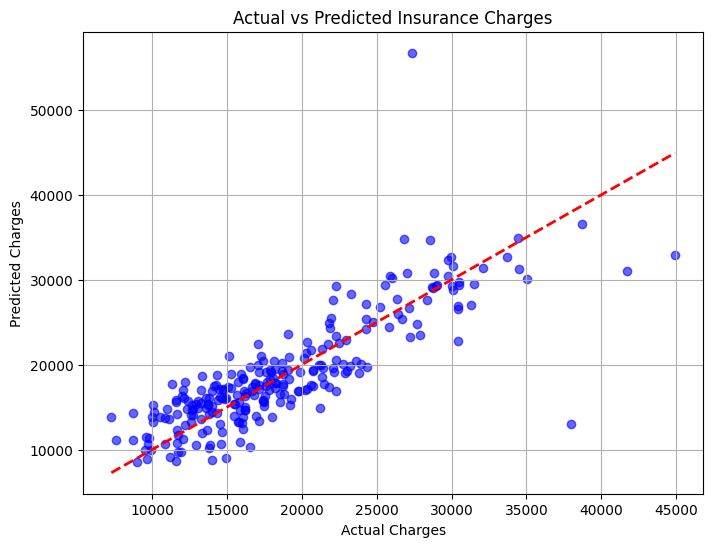

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Perfect fit line
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.grid(True)
plt.show()

# Clustering
The clustering aims to discover groups of customers with similar characteristics without using a predefined target variable.
K-Means clustering is used to identify hidden patterns within the insurance customer data.

In [26]:
# Select clustering Features
X_cluster = df[
    ["age", "bmi", "annual_income"]
].copy()
X_cluster.head()

,age,bmi,annual_income
0,42,17.96,68686.20
1,39,22.35,24547.41
2,25,29.33,60931.43
3,61,34.52,48223.81
4,42,24.79,61435.93


In [27]:
# Now apply standardscaler before k-means clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled[:5]

array([[ 0.00870965, -1.79173228,  0.24524435],
       [-0.20781217, -1.08738564, -1.49162775],
       [-1.21824734,  0.03250948, -0.05990773],
       [ 1.38001451,  0.86521086, -0.55995566],
       [ 0.00870965, -0.69590368, -0.04005554]])

### Elbow Method  
Apply To find the optimal number of clusters ($K$) for K-Means clustering.

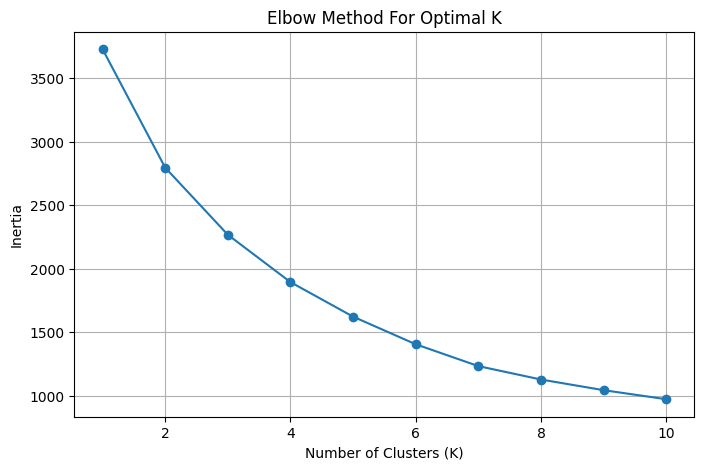

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

### Plot Elbow Graph

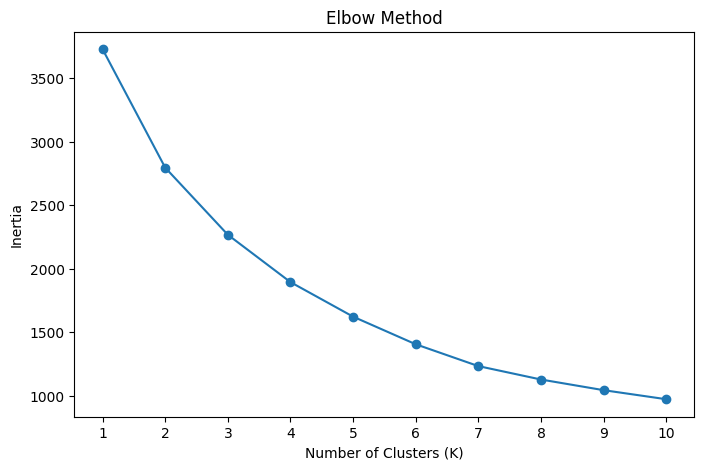

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.show()

## Choosing the Number of Clusters
Based on the Elbow Method plot, K = 3 is selected as a reasonable number of clusters because the decrease in inertia slows down after this point.
Therefore, three clusters are used for the final K-Means model.

In [30]:
# chose  K
chosen_k = 3

In [31]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Get cluster Labels

In [32]:
cluster_labels = kmeans.labels_
print(cluster_labels)

[2 2 1 ... 0 2 0]


### Add cluster to dataset

In [33]:
df["Cluster"] = cluster_labels
df.head()

,customer_id,age,sex,bmi,children,smoker,region,exercise_level,chronic_condition,annual_income,claim_count,charges,Cluster
0,CUST-1207,42,female,17.96,4,no,west,medium,none,68686.20,1,15707.20,2
1,CUST-0869,39,female,22.35,0,yes,west,low,none,24547.41,1,25646.56,2
2,CUST-0533,25,male,29.33,1,no,south,low,none,60931.43,2,13613.91,1
3,CUST-0345,61,female,34.52,0,no,east,low,none,48223.81,1,19584.48,0
4,CUST-0406,42,male,24.79,2,yes,west,low,none,61435.93,2,28675.27,2


### check 2D cluster visualisation

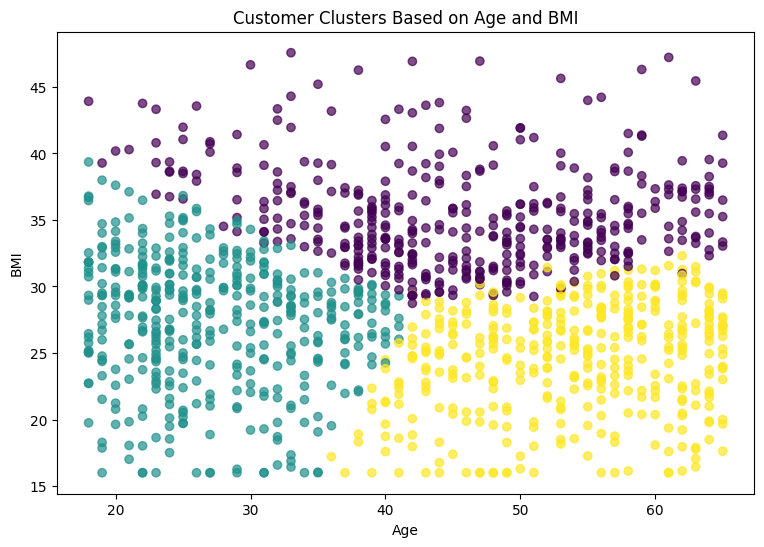

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.scatter(
    df["age"],
    df["bmi"],
    c=df["Cluster"],
    alpha=0.7
)
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Customer Clusters Based on Age and BMI")
plt.show()

### Analyze Cluster Characteristics

In [35]:
cluster_summary = df.groupby("Cluster")[
    ["age", "bmi", "annual_income", "children", "claim_count", "charges"]
].mean()
cluster_summary

,age,bmi,annual_income,children,claim_count,charges
Cluster,,,,,,
0,45.518957,35.251754,65250.171517,1.938389,1.395735,20943.798578
1,27.255269,27.255176,62234.480375,2.030445,1.433255,16215.294309
2,53.829949,24.596777,59696.559467,1.934010,1.365482,21545.382944


## Cluster Interpretation

The K-Means algorithm divided the customers into three distinct groups based on age, BMI, and annual income:

- Cluster 0 (Middle-Aged, High BMI & High Charges):** Average age around 45.5 years with the highest average BMI (35.25) and highest average income ($65,250)[cite: 18]. They incur high average medical charges ($20,943)[cite: 18].
- Cluster 1 (Young Adults, Low Charges):** Youngest segment with an average age of 27.2 years and moderate BMI (27.25)[cite: 18]. They have the lowest average medical charges ($16,215)[cite: 18].
- Cluster 2 (Older Adults, Healthy BMI & Highest Charges):** Oldest segment with an average age of 53.8 years and lower/healthier BMI (24.6)[cite: 18]. Due to age factor, they incur the highest average charges ($21,545)[cite: 18].

These segments provide clear customer profiling for targeted risk assessment and insurance premium strategy.

#  Conclusion

This project demonstrated both supervised and unsupervised machine learning techniques using a medical insurance dataset.

For the regression task, a Random Forest Regressor was trained to predict the continuous insurance `charges` variable. The model was evaluated using RMSE and R².

For the clustering task, three numerical features were standardized and K-Means clustering was applied. The Elbow Method was used to determine a reasonable number of clusters, and the resulting customer groups were visualized in two dimensions.

The project also demonstrated an end-to-end data science workflow including data inspection, cleaning, preprocessing, model training, evaluation, visualization, and interpretation.